## Import and Load Data

In [1]:
import pandas as pd
import numpy as np

%matplotlib inline

In [3]:
#%pip install pyarrow

In [2]:
trip_jan_2019 = pd.read_parquet(r'F:\Users\ENET\Downloads\yellow_tripdata_2019-01.parquet')
trip_data = pd.concat([trip_jan_2019])

## Exploartory Analysis and Cleaning

In [3]:
print(trip_data.shape)
trip_data.head()

(7696617, 19)


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee
0,1,2019-01-01 00:46:40,2019-01-01 00:53:20,1.0,1.5,1.0,N,151,239,1,7.0,0.5,0.5,1.65,0.0,0.3,9.95,NaN,None
1,1,2019-01-01 00:59:47,2019-01-01 01:18:59,1.0,2.6,1.0,N,239,246,1,14.0,0.5,0.5,1.00,0.0,0.3,16.30,NaN,None
2,2,2018-12-21 13:48:30,2018-12-21 13:52:40,3.0,0.0,1.0,N,236,236,1,4.5,0.5,0.5,0.00,0.0,0.3,5.80,NaN,None
3,2,2018-11-28 15:52:25,2018-11-28 15:55:45,5.0,0.0,1.0,N,193,193,2,3.5,0.5,0.5,0.00,0.0,0.3,7.55,NaN,None
4,2,2018-11-28 15:56:57,2018-11-28 15:58:33,5.0,0.0,2.0,N,193,193,2,52.0,0.0,0.5,0.00,0.0,0.3,55.55,NaN,None


In [4]:
trip_data.describe

<bound method NDFrame.describe of          VendorID tpep_pickup_datetime tpep_dropoff_datetime  passenger_count  \
0               1  2019-01-01 00:46:40   2019-01-01 00:53:20              1.0   
1               1  2019-01-01 00:59:47   2019-01-01 01:18:59              1.0   
2               2  2018-12-21 13:48:30   2018-12-21 13:52:40              3.0   
3               2  2018-11-28 15:52:25   2018-11-28 15:55:45              5.0   
4               2  2018-11-28 15:56:57   2018-11-28 15:58:33              5.0   
...           ...                  ...                   ...              ...   
7696612         2  2019-01-31 23:37:20   2019-02-01 00:10:43              NaN   
7696613         2  2019-01-31 23:28:00   2019-01-31 23:50:50              NaN   
7696614         2  2019-01-31 23:11:00   2019-01-31 23:46:00              NaN   
7696615         2  2019-01-31 23:03:00   2019-01-31 23:14:00              NaN   
7696616         2  2019-01-31 23:41:03   2019-02-01 00:19:16              N

In [5]:
trip_data.columns

Index(['VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime',
       'passenger_count', 'trip_distance', 'RatecodeID', 'store_and_fwd_flag',
       'PULocationID', 'DOLocationID', 'payment_type', 'fare_amount', 'extra',
       'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge',
       'total_amount', 'congestion_surcharge', 'airport_fee'],
      dtype='object')

In [6]:
trip_data = trip_data[['tpep_pickup_datetime', 'tpep_dropoff_datetime',
       'passenger_count', 'trip_distance', 'RatecodeID', 'store_and_fwd_flag',
       'PULocationID', 'DOLocationID', 'payment_type',
       'total_amount']]

In [7]:
trip_data.head()

,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,total_amount
0,2019-01-01 00:46:40,2019-01-01 00:53:20,1.0,1.5,1.0,N,151,239,1,9.95
1,2019-01-01 00:59:47,2019-01-01 01:18:59,1.0,2.6,1.0,N,239,246,1,16.30
2,2018-12-21 13:48:30,2018-12-21 13:52:40,3.0,0.0,1.0,N,236,236,1,5.80
3,2018-11-28 15:52:25,2018-11-28 15:55:45,5.0,0.0,1.0,N,193,193,2,7.55
4,2018-11-28 15:56:57,2018-11-28 15:58:33,5.0,0.0,2.0,N,193,193,2,55.55


array([[<Axes: title={'center': 'tpep_pickup_datetime'}>,
        <Axes: title={'center': 'tpep_dropoff_datetime'}>,
        <Axes: title={'center': 'passenger_count'}>],
       [<Axes: title={'center': 'trip_distance'}>,
        <Axes: title={'center': 'RatecodeID'}>,
        <Axes: title={'center': 'PULocationID'}>],
       [<Axes: title={'center': 'DOLocationID'}>,
        <Axes: title={'center': 'payment_type'}>,
        <Axes: title={'center': 'total_amount'}>]], dtype=object)

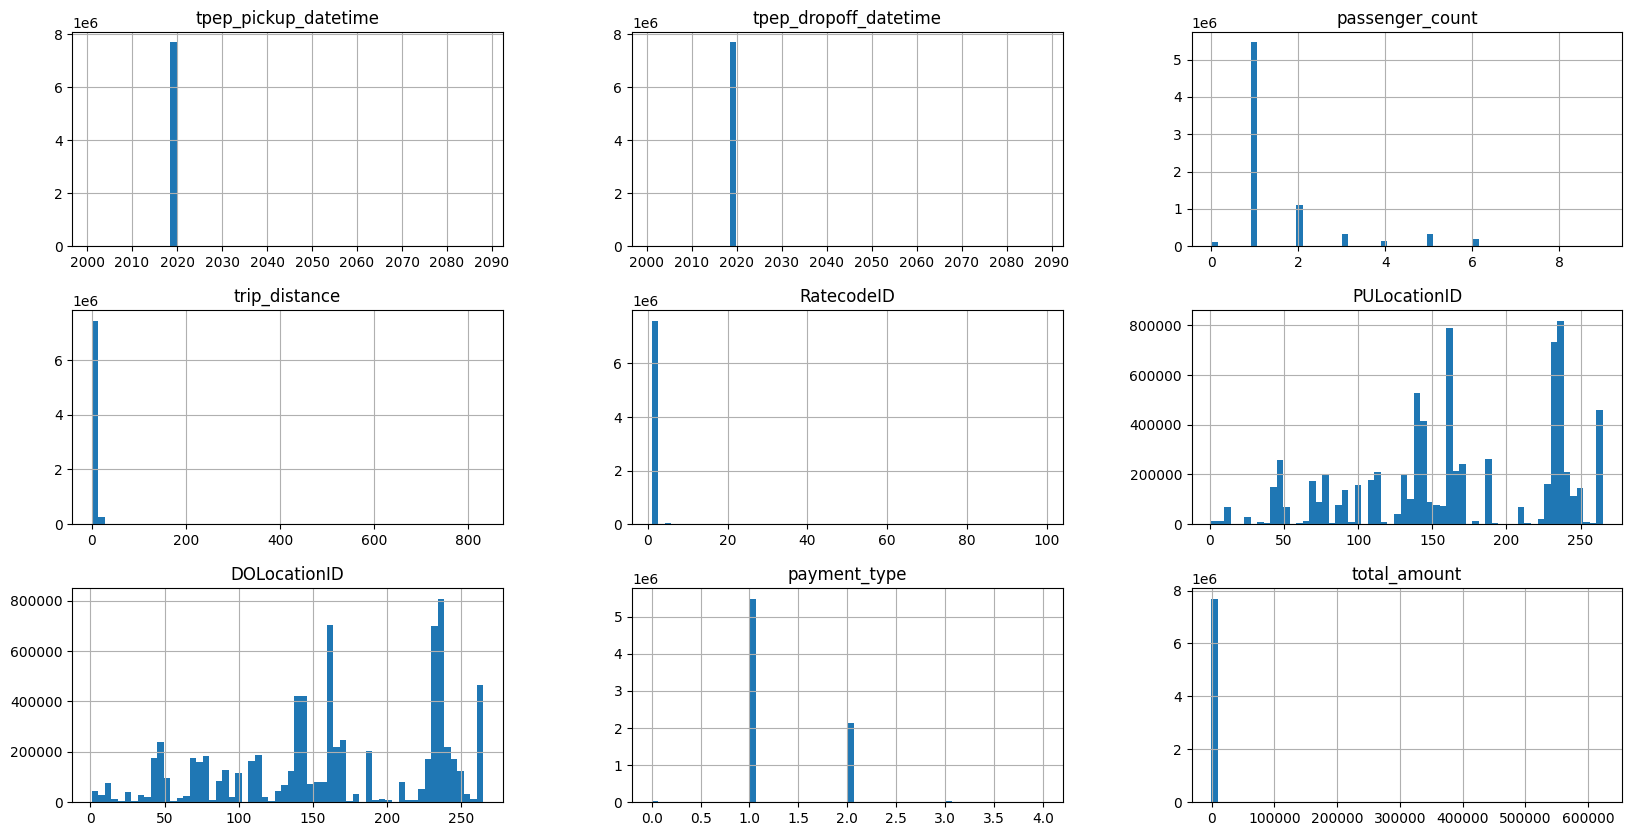

In [8]:
trip_data.hist(figsize=(20,10), bins=60)

In [9]:
trip_data['RatecodeID'].value_counts()

RatecodeID
1.0     7430288
2.0      166093
5.0       54570
3.0       11801
4.0        4895
99.0        252
6.0          46
Name: count, dtype: int64

<Axes: xlabel='index', ylabel='total_amount'>

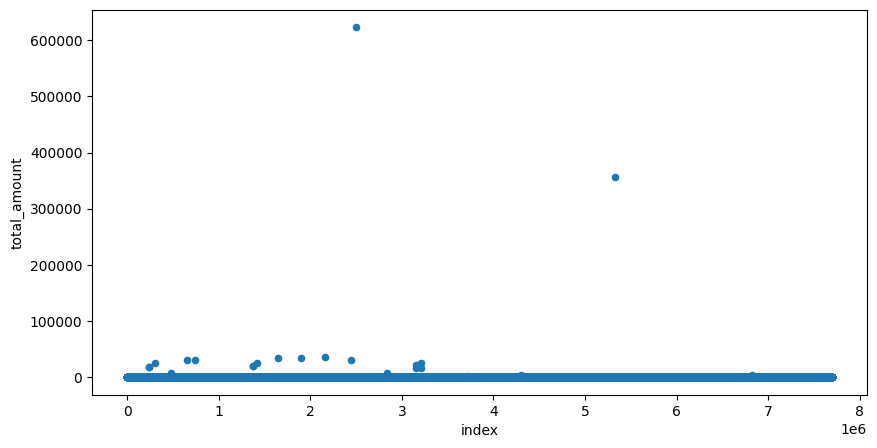

In [10]:
trip_data.reset_index().plot(kind= 'scatter', y= 'total_amount', x= 'index', figsize=(10,5))


<Axes: xlabel='index', ylabel='total_amount'>

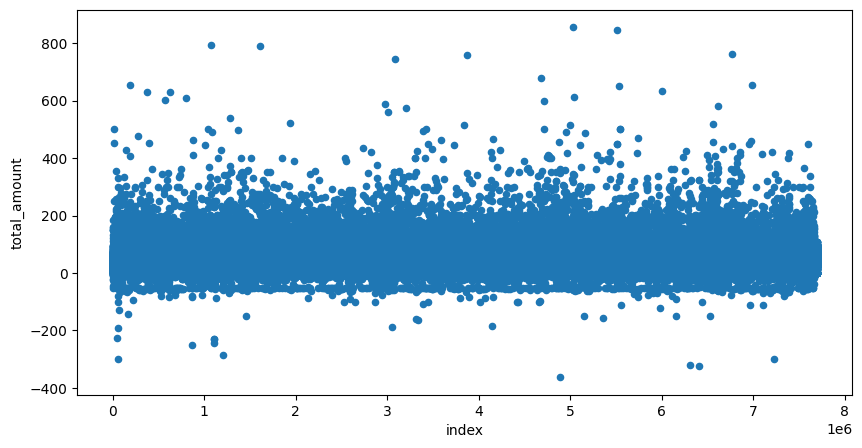

In [11]:
trip_data[trip_data['total_amount']<1000].reset_index().plot(kind= 'scatter', y= 'total_amount', x= 'index', figsize=(10,5))

(7127, 10)


<Axes: xlabel='index', ylabel='total_amount'>

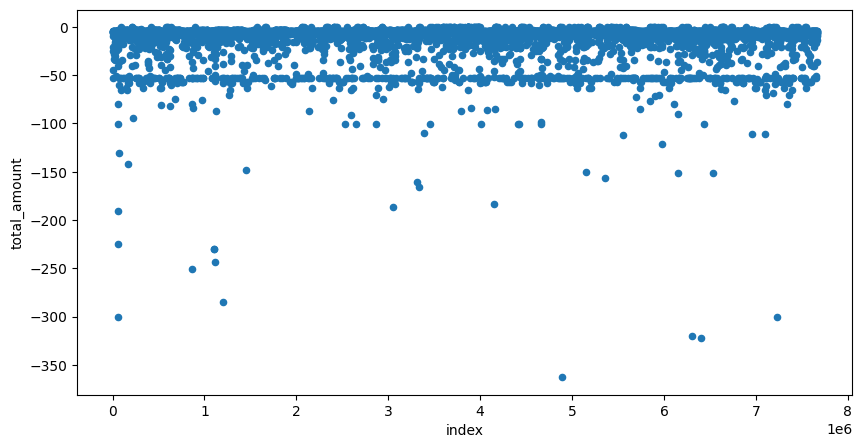

In [12]:
print(trip_data[trip_data['total_amount']<0].shape)
trip_data[trip_data['total_amount']<0].reset_index().plot(kind= 'scatter', y= 'total_amount', x= 'index', figsize=(10,5))

In [13]:
trip_data[trip_data['total_amount']<0].head()

,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,total_amount
663,2019-01-01 00:32:56,2019-01-01 00:33:35,2.0,0.10,1.0,N,148,148,3,-3.8
2402,2019-01-01 00:14:18,2019-01-01 00:40:55,1.0,4.13,1.0,N,170,238,4,-20.3
2541,2019-01-01 00:31:27,2019-01-01 00:42:39,1.0,1.35,1.0,N,162,234,4,-9.8
2544,2019-01-01 00:45:57,2019-01-01 00:46:07,1.0,0.00,1.0,N,234,234,4,-3.8
2547,2019-01-01 00:48:35,2019-01-01 00:49:59,1.0,0.16,1.0,N,234,234,4,-4.3


In [14]:
#from ydata_profiling import ProfileReport

#Generate Report
#proflie = ProfileReport(trip_data, title = "Trip_Analysis_Report", explorative = True)

#Save it to view
#proflie.to_file("analysis_report.html")

In [15]:
trip_data[trip_data['total_amount']<0]['payment_type'].value_counts()

payment_type
3    4083
4    2667
2     376
1       1
Name: count, dtype: int64

<Axes: >

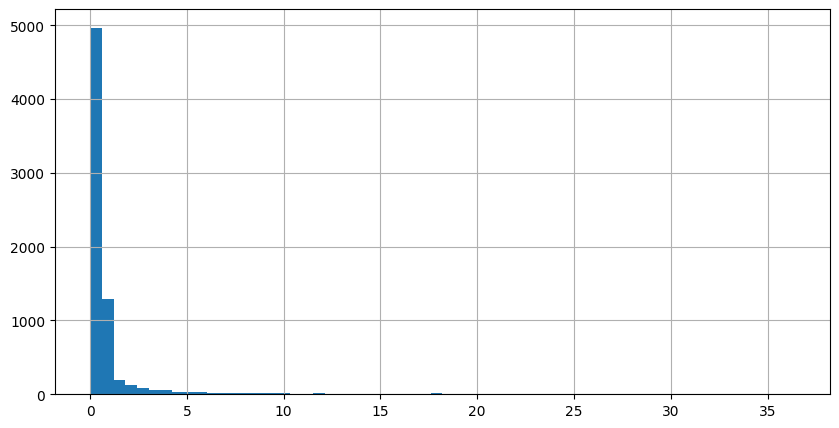

In [16]:
trip_data[trip_data['total_amount']<0]['trip_distance'].hist(bins=60, figsize=(10,5))

In [17]:
print(trip_data[trip_data['total_amount']==0].shape)
trip_data[trip_data['total_amount']==0].head()

(1643, 10)


,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,total_amount
3552,2019-01-01 00:18:46,2019-01-01 00:18:46,1.0,0.0,5.0,N,186,264,2,0.0
9138,2019-01-01 00:41:47,2019-01-01 00:41:47,1.0,0.0,5.0,Y,246,264,2,0.0
13256,2019-01-01 00:19:38,2019-01-01 00:20:35,1.0,0.0,1.0,N,193,193,1,0.0
13257,2019-01-01 00:43:34,2019-01-01 00:43:34,1.0,0.0,1.0,N,7,7,2,0.0
13258,2019-01-01 00:02:52,2019-01-01 00:02:52,1.0,0.0,1.0,N,264,7,2,0.0


In [18]:
trip_data[trip_data['total_amount']==0]['payment_type'].value_counts()

payment_type
1    813
2    569
0    231
3     29
4      1
Name: count, dtype: int64

<Axes: >

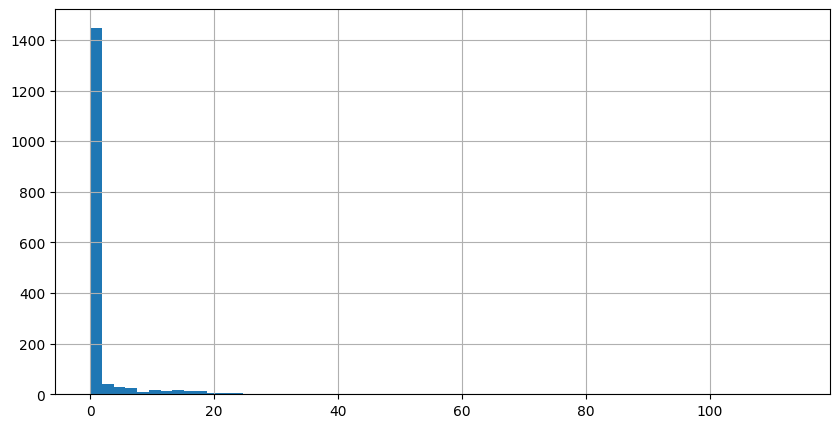

In [19]:
trip_data[trip_data['total_amount']==0]['trip_distance'].hist(bins=60, figsize=(10,5))

<Axes: xlabel='index', ylabel='total_amount'>

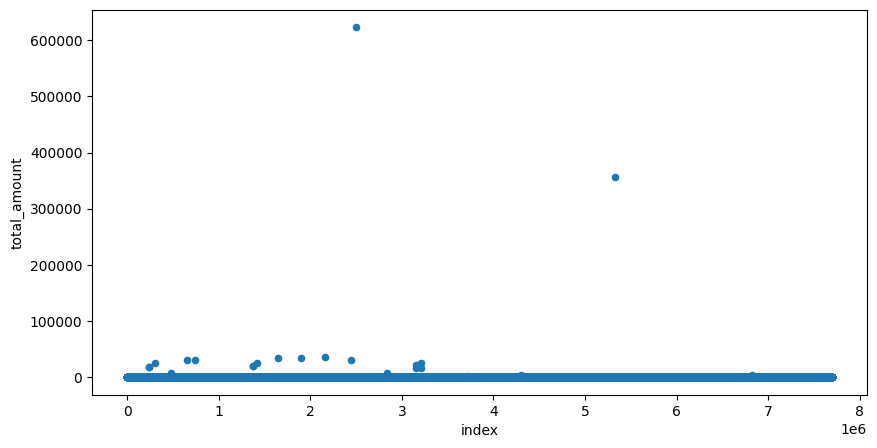

In [20]:
trip_data.reset_index().plot(kind= 'scatter', y= 'total_amount', x= 'index', figsize=(10,5))

In [21]:
trip_data[trip_data['total_amount']>200].shape

(1166, 10)

In [22]:
trip_data['total_amount'].mean()

15.810651344610214

In [23]:
trip_data_cleaned = trip_data[(trip_data['total_amount']>=0) & (trip_data['total_amount']<200)]

In [24]:
print(trip_data.shape)
trip_data_cleaned.shape

(7696617, 10)


(7688319, 10)

In [25]:
trip_data_cleaned.isnull().sum()

tpep_pickup_datetime         0
tpep_dropoff_datetime        0
passenger_count          28672
trip_distance                0
RatecodeID               28672
store_and_fwd_flag       28672
PULocationID                 0
DOLocationID                 0
payment_type                 0
total_amount                 0
dtype: int64

In [26]:
trip_data_cleaned = trip_data_cleaned.dropna()
trip_data_cleaned.shape

(7659647, 10)

In [27]:
trip_data_cleaned.isnull().sum()

tpep_pickup_datetime     0
tpep_dropoff_datetime    0
passenger_count          0
trip_distance            0
RatecodeID               0
store_and_fwd_flag       0
PULocationID             0
DOLocationID             0
payment_type             0
total_amount             0
dtype: int64

In [28]:
trip_data_prepared = trip_data_cleaned.copy()

In [29]:
trip_data_prepared.dtypes

tpep_pickup_datetime     datetime64[us]
tpep_dropoff_datetime    datetime64[us]
passenger_count                 float64
trip_distance                   float64
RatecodeID                      float64
store_and_fwd_flag               object
PULocationID                      int64
DOLocationID                      int64
payment_type                      int64
total_amount                    float64
dtype: object

In [30]:
# Changing Date Columns to type Datetime
trip_data_prepared.loc [:,'tpep_pickup_datetime'] = pd.to_datetime (trip_data_prepared.loc [:,'tpep_pickup_datetime'])
trip_data_prepared.loc [:,'tpep_dropoff_datetime'] = pd.to_datetime (trip_data_prepared.loc [:,'tpep_dropoff_datetime'])

In [31]:
# Changing columns datatype to string
trip_data_prepared.loc[:,'RatecodeID'] = trip_data_prepared ['RatecodeID'].astype(str)
trip_data_prepared.loc[:,'PULocationID'] = trip_data_prepared ['PULocationID'].astype(str)
trip_data_prepared.loc[:,'DOLocationID'] = trip_data_prepared ['DOLocationID'].astype(str)
trip_data_prepared.loc[:,'payment_type'] = trip_data_prepared ['payment_type'].astype(str)

C:\Users\HP\AppData\Local\Temp\ipykernel_15540\3093436836.py:1: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '['1.0' '1.0' '1.0' ... '1.0' '1.0' '1.0']' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  trip_data_prepared.loc[:,'RatecodeID'] = trip_data_prepared ['RatecodeID'].astype(str)
C:\Users\HP\AppData\Local\Temp\ipykernel_15540\3093436836.py:2: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '['151' '239' '236' ... '264' '264' '193']' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  trip_data_prepared.loc[:,'PULocationID'] = trip_data_prepared ['PULocationID'].astype(str)
C:\Users\HP\AppData\Local\Temp\ipykernel_15540\3093436836.py:3: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '['239' '24

In [32]:
trip_data_prepared.dtypes

tpep_pickup_datetime     datetime64[us]
tpep_dropoff_datetime    datetime64[us]
passenger_count                 float64
trip_distance                   float64
RatecodeID                       object
store_and_fwd_flag               object
PULocationID                     object
DOLocationID                     object
payment_type                     object
total_amount                    float64
dtype: object

In [33]:
trip_data_prepared.head()

,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,total_amount
0,2019-01-01 00:46:40,2019-01-01 00:53:20,1.0,1.5,1.0,N,151,239,1,9.95
1,2019-01-01 00:59:47,2019-01-01 01:18:59,1.0,2.6,1.0,N,239,246,1,16.30
2,2018-12-21 13:48:30,2018-12-21 13:52:40,3.0,0.0,1.0,N,236,236,1,5.80
3,2018-11-28 15:52:25,2018-11-28 15:55:45,5.0,0.0,1.0,N,193,193,2,7.55
4,2018-11-28 15:56:57,2018-11-28 15:58:33,5.0,0.0,2.0,N,193,193,2,55.55


In [34]:
# Extracting Year,Month,Day and Hour from the pick up date
trip_data_prepared['transaction_date'] = pd.to_datetime(trip_data_prepared['tpep_pickup_datetime'].dt.date)
trip_data_prepared['transaction_year'] = trip_data_prepared ['tpep_pickup_datetime'].dt.year
trip_data_prepared['transaction_month'] = trip_data_prepared ['tpep_pickup_datetime'].dt.month
trip_data_prepared['transaction_day'] = trip_data_prepared ['tpep_pickup_datetime'].dt.day
trip_data_prepared['transaction_hour'] = trip_data_prepared ['tpep_pickup_datetime'].dt.hour

In [35]:
trip_data_prepared.head()

,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,total_amount,transaction_date,transaction_year,transaction_month,transaction_day,transaction_hour
0,2019-01-01 00:46:40,2019-01-01 00:53:20,1.0,1.5,1.0,N,151,239,1,9.95,2019-01-01,2019,1,1,0
1,2019-01-01 00:59:47,2019-01-01 01:18:59,1.0,2.6,1.0,N,239,246,1,16.30,2019-01-01,2019,1,1,0
2,2018-12-21 13:48:30,2018-12-21 13:52:40,3.0,0.0,1.0,N,236,236,1,5.80,2018-12-21,2018,12,21,13
3,2018-11-28 15:52:25,2018-11-28 15:55:45,5.0,0.0,1.0,N,193,193,2,7.55,2018-11-28,2018,11,28,15
4,2018-11-28 15:56:57,2018-11-28 15:58:33,5.0,0.0,2.0,N,193,193,2,55.55,2018-11-28,2018,11,28,15


array([[<Axes: title={'center': 'tpep_pickup_datetime'}>,
        <Axes: title={'center': 'tpep_dropoff_datetime'}>,
        <Axes: title={'center': 'passenger_count'}>],
       [<Axes: title={'center': 'trip_distance'}>,
        <Axes: title={'center': 'total_amount'}>,
        <Axes: title={'center': 'transaction_date'}>],
       [<Axes: title={'center': 'transaction_year'}>,
        <Axes: title={'center': 'transaction_month'}>,
        <Axes: title={'center': 'transaction_day'}>],
       [<Axes: title={'center': 'transaction_hour'}>, <Axes: >, <Axes: >]],
      dtype=object)

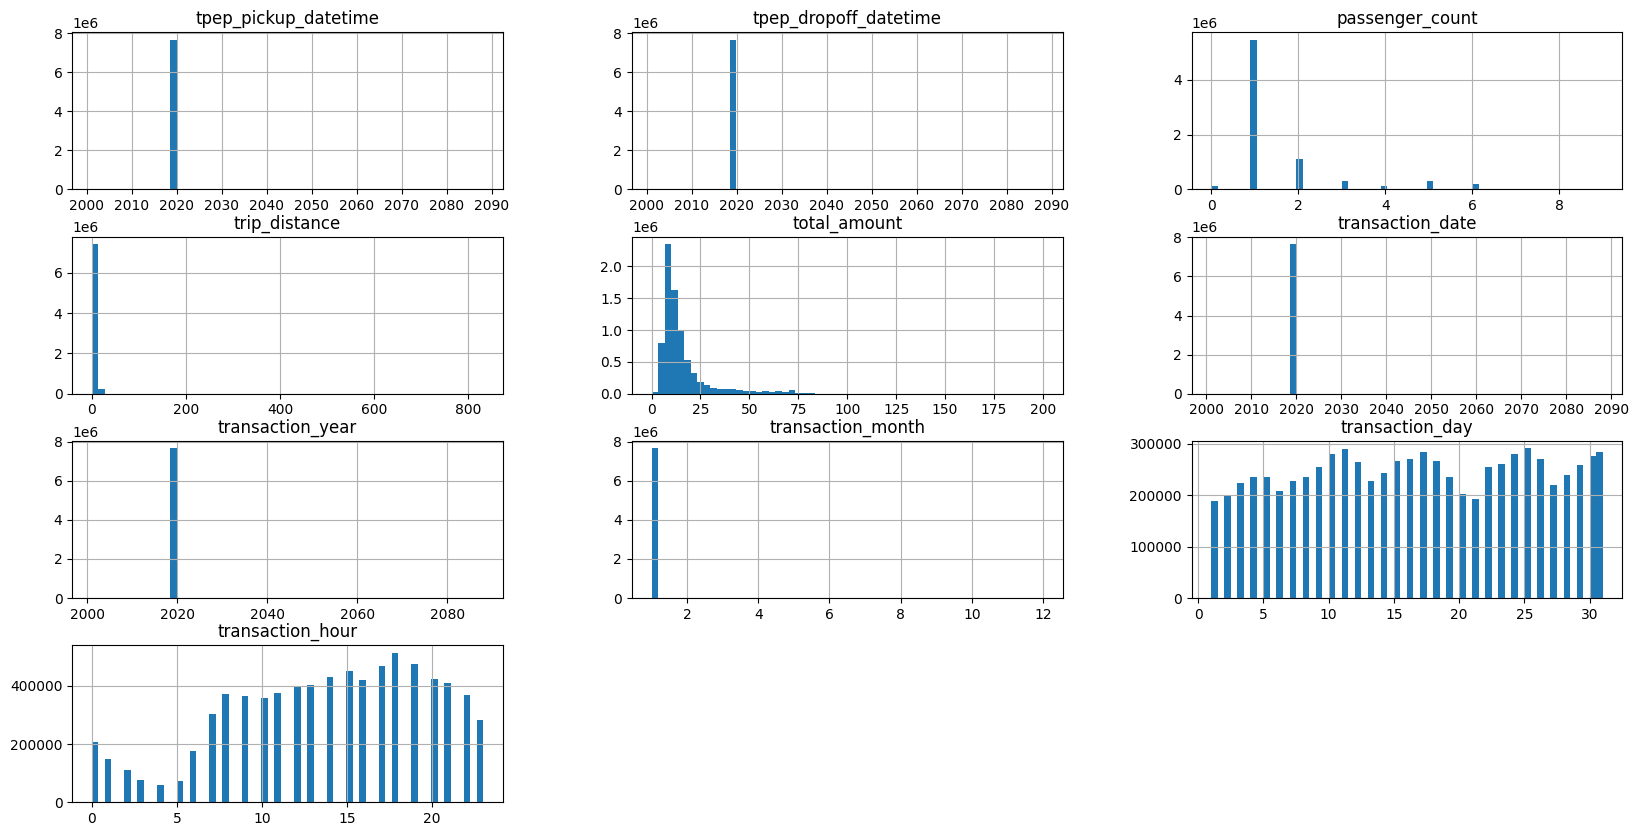

In [36]:
trip_data_prepared.hist(bins=60, figsize=(20,10))

In [37]:
# Project focus on trips that occured in january 2019
trip_data_prepared = trip_data_prepared[trip_data_prepared['transaction_year']== 2019]
trip_data_prepared = trip_data_prepared[trip_data_prepared['transaction_month']==1]

In [38]:
categorical_columns = ['PULocationID', 'transaction_date', 'transaction_month', 'transaction_day', 'transaction_hour',]
numerical_columns = ['trip_distance', 'total_amount']
all_needed_columns = categorical_columns + numerical_columns

In [39]:
main_taxi_df = trip_data_prepared[all_needed_columns]
print(main_taxi_df.shape)
main_taxi_df.head()

(7659111, 7)


,PULocationID,transaction_date,transaction_month,transaction_day,transaction_hour,trip_distance,total_amount
0,151,2019-01-01,1,1,0,1.5,9.95
1,239,2019-01-01,1,1,0,2.6,16.30
7,163,2019-01-01,1,1,0,1.3,9.05
8,229,2019-01-01,1,1,0,3.7,18.50
9,141,2019-01-01,1,1,0,2.1,13.00


In [40]:
main_taxi_df.tail()

,PULocationID,transaction_date,transaction_month,transaction_day,transaction_hour,trip_distance,total_amount
7667940,263,2019-01-31,1,31,23,4.79,23.16
7667941,193,2019-01-31,1,31,23,0.00,0.00
7667942,264,2019-01-31,1,31,23,0.00,0.00
7667943,264,2019-01-31,1,31,23,0.00,0.00
7667944,193,2019-01-31,1,31,23,0.00,0.00


In [41]:
taxi_grouped_by_region = main_taxi_df.groupby(categorical_columns).mean().reset_index()
taxi_grouped_by_region['count_of_transaction'] = main_taxi_df.groupby(categorical_columns).count().reset_index()['total_amount']
print(taxi_grouped_by_region.shape)
taxi_grouped_by_region.head()

(102496, 8)


,PULocationID,transaction_date,transaction_month,transaction_day,transaction_hour,trip_distance,total_amount,count_of_transaction
0,1,2019-01-01,1,1,2,0.0,21.800,1
1,1,2019-01-01,1,1,5,0.0,87.300,1
2,1,2019-01-01,1,1,6,0.0,80.300,1
3,1,2019-01-01,1,1,8,0.0,128.580,2
4,1,2019-01-01,1,1,10,16.9,43.245,4


<Axes: >

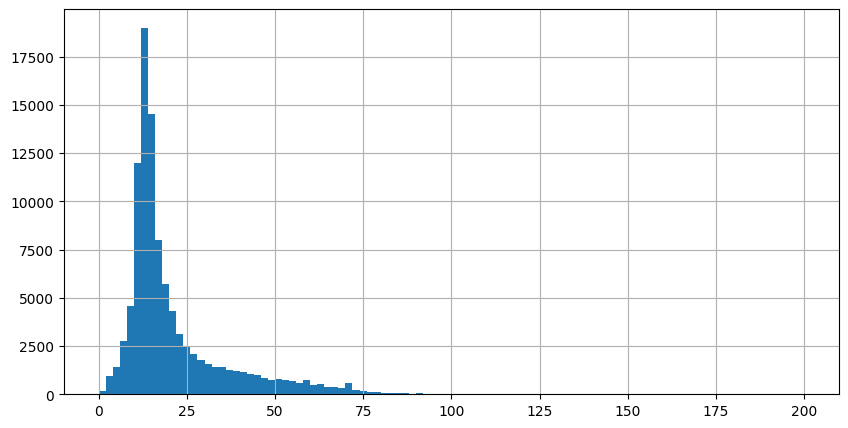

In [42]:
taxi_grouped_by_region['total_amount'].hist(bins=100, figsize=(10,5))

<Axes: >

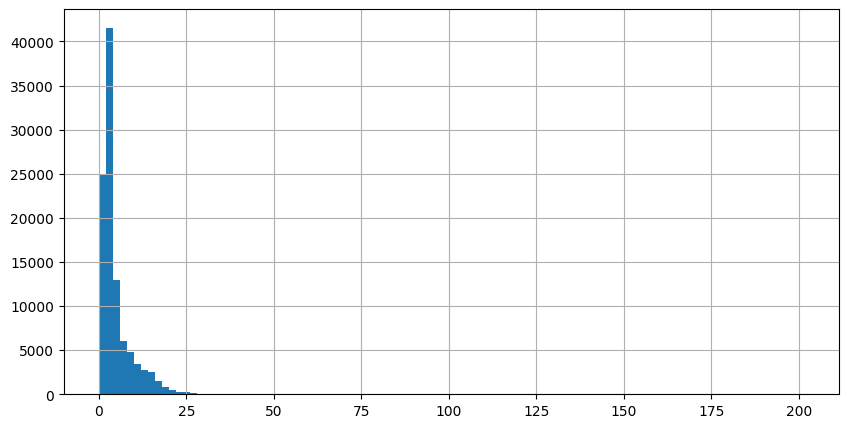

In [43]:
taxi_grouped_by_region['trip_distance'].hist(bins=100, figsize=(10,5))

## Benchmark Model

In [44]:
data_for_benchmark_model = taxi_grouped_by_region.copy()

In [45]:
categorical_features_benchmark = ['PULocationID', 'transaction_month', 'transaction_day','transaction_hour']
input_features_benchmark = categorical_features_benchmark + ['trip_distance']
target_features_benchmark = ['total_amount']

In [48]:
#pip install scikit-learn

In [46]:
import sklearn

In [47]:
from sklearn.model_selection import train_test_split
X_data = data_for_benchmark_model[input_features_benchmark]
y_data = data_for_benchmark_model[target_features_benchmark]

X_data = pd.get_dummies(X_data)

X_train,X_test,y_train,y_test = train_test_split(X_data, y_data, test_size=0.30, random_state=42)

In [48]:
print(X_train.shape)
print(y_train.shape)

(71747, 267)
(71747, 1)


In [49]:
from sklearn.tree import DecisionTreeRegressor

In [50]:
tree = DecisionTreeRegressor(max_depth=10)
tree.fit(X_train,y_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [51]:
model_at_hand = tree

y_pred = model_at_hand.predict(X_test)
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
from math import sqrt

print('mean_absolute_error', mean_absolute_error(y_test, y_pred))
print('mean_squared_error', mean_squared_error(y_test, y_pred))
print('root_mean_squared_error', sqrt(mean_squared_error(y_test, y_pred)))
print('r2', r2_score(y_test, y_pred))

mean_absolute_error 3.3846927525351354
mean_squared_error 66.17344573819264
root_mean_squared_error 8.134706247812066
r2 0.7623805319170259


<Axes: xlabel='true', ylabel='pred'>

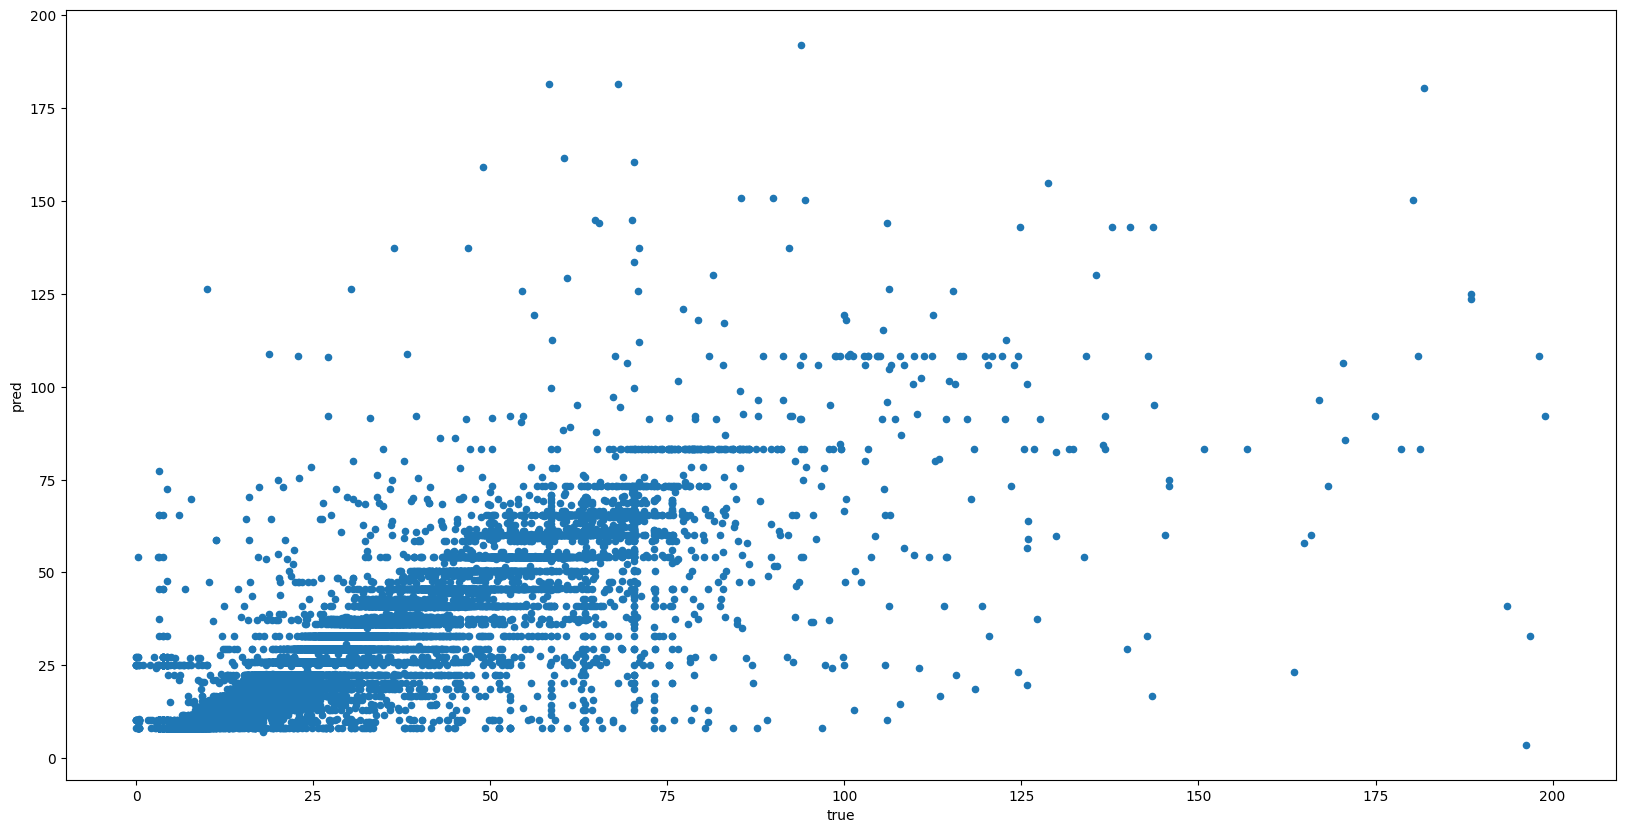

In [52]:
data = {
    'true': np.ravel(y_test),
    'pred': np.ravel(y_pred)
}
results = pd.DataFrame(data)

results.plot(figsize=(20,10), kind='scatter', x='true', y='pred')

<Axes: xlabel='true', ylabel='pred'>

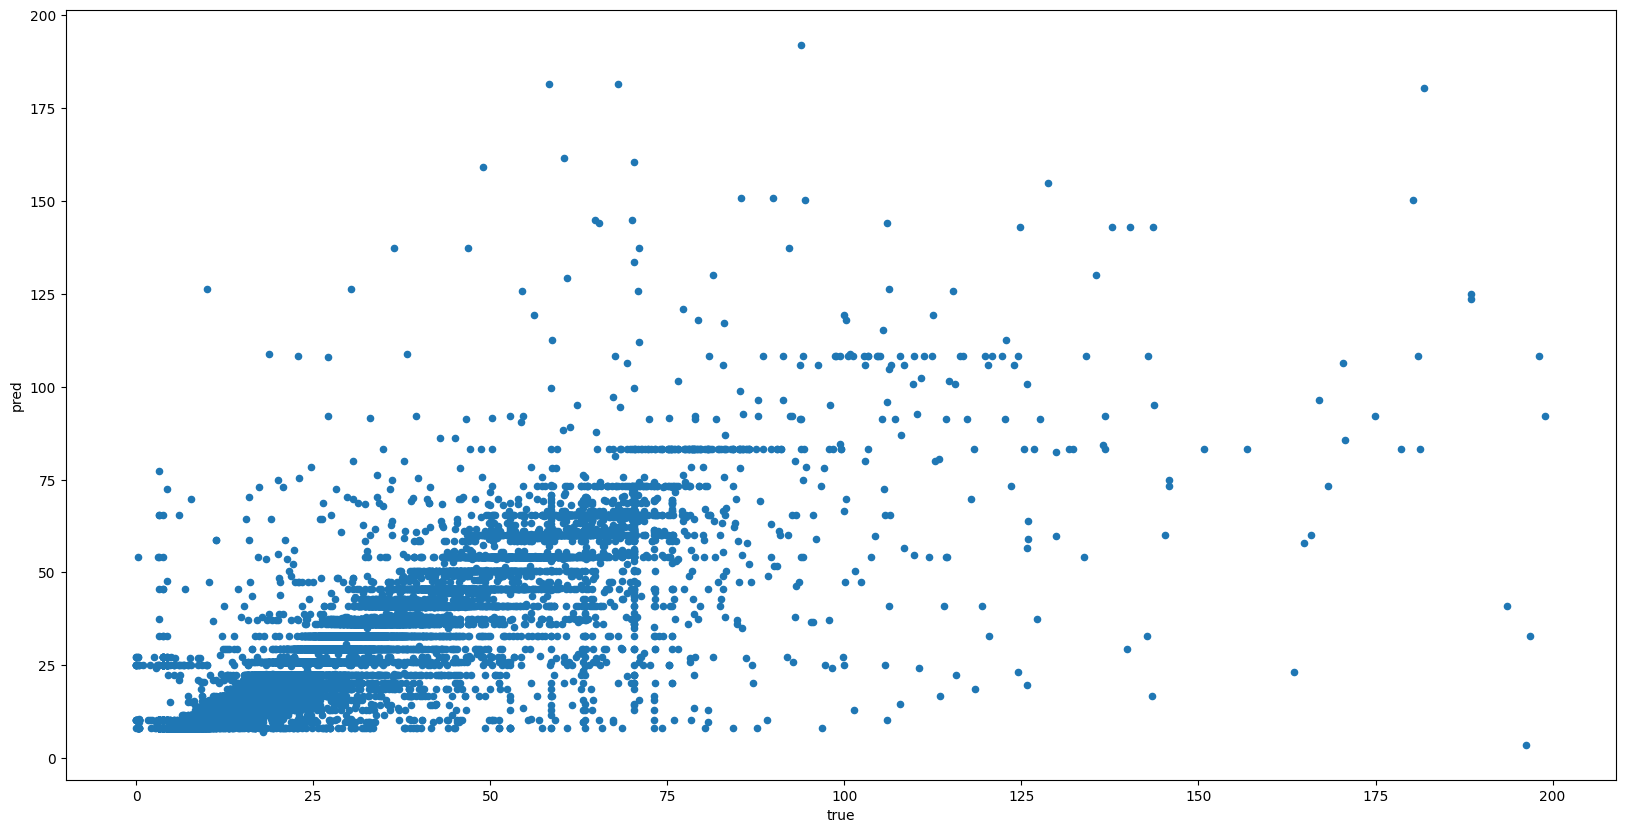

In [53]:
import numpy as np
data = {
    'true': np.ravel(y_test),
    'pred': np.ravel(y_pred)
}
results = pd.DataFrame(data)

results.plot(figsize=(20, 10), kind='scatter', x='true', y='pred')

### Fixing the Distribution Problem

In [54]:
#Remove trip_distance from input features

categorical_features_benchmark = ['PULocationID', 'transaction_month', 'transaction_day','transaction_hour']
input_features_benchmark = categorical_features_benchmark
target_features_benchmark = ['total_amount']

from sklearn.model_selection import train_test_split
X_data = data_for_benchmark_model[input_features_benchmark]
y_data = data_for_benchmark_model[target_features_benchmark]

X_data = pd.get_dummies(X_data)

X_train,X_test,y_train,y_test = train_test_split(X_data, y_data, test_size=0.30, random_state=42)

from sklearn.tree import DecisionTreeRegressor
tree = DecisionTreeRegressor(max_depth=10)
tree.fit(X_train,y_train)

model_at_hand = tree

y_pred = model_at_hand.predict(X_test)
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
from math import sqrt

print('mean_absolute_error', mean_absolute_error(y_test, y_pred))
print('mean_squared_error', mean_squared_error(y_test, y_pred))
print('root_mean_squared_error', sqrt(mean_squared_error(y_test, y_pred)))
print('r2', r2_score(y_test, y_pred))

mean_absolute_error 9.806173927458463
mean_squared_error 220.5563644151031
root_mean_squared_error 14.85114017222594
r2 0.208013344174651


<Axes: xlabel='true', ylabel='pred'>

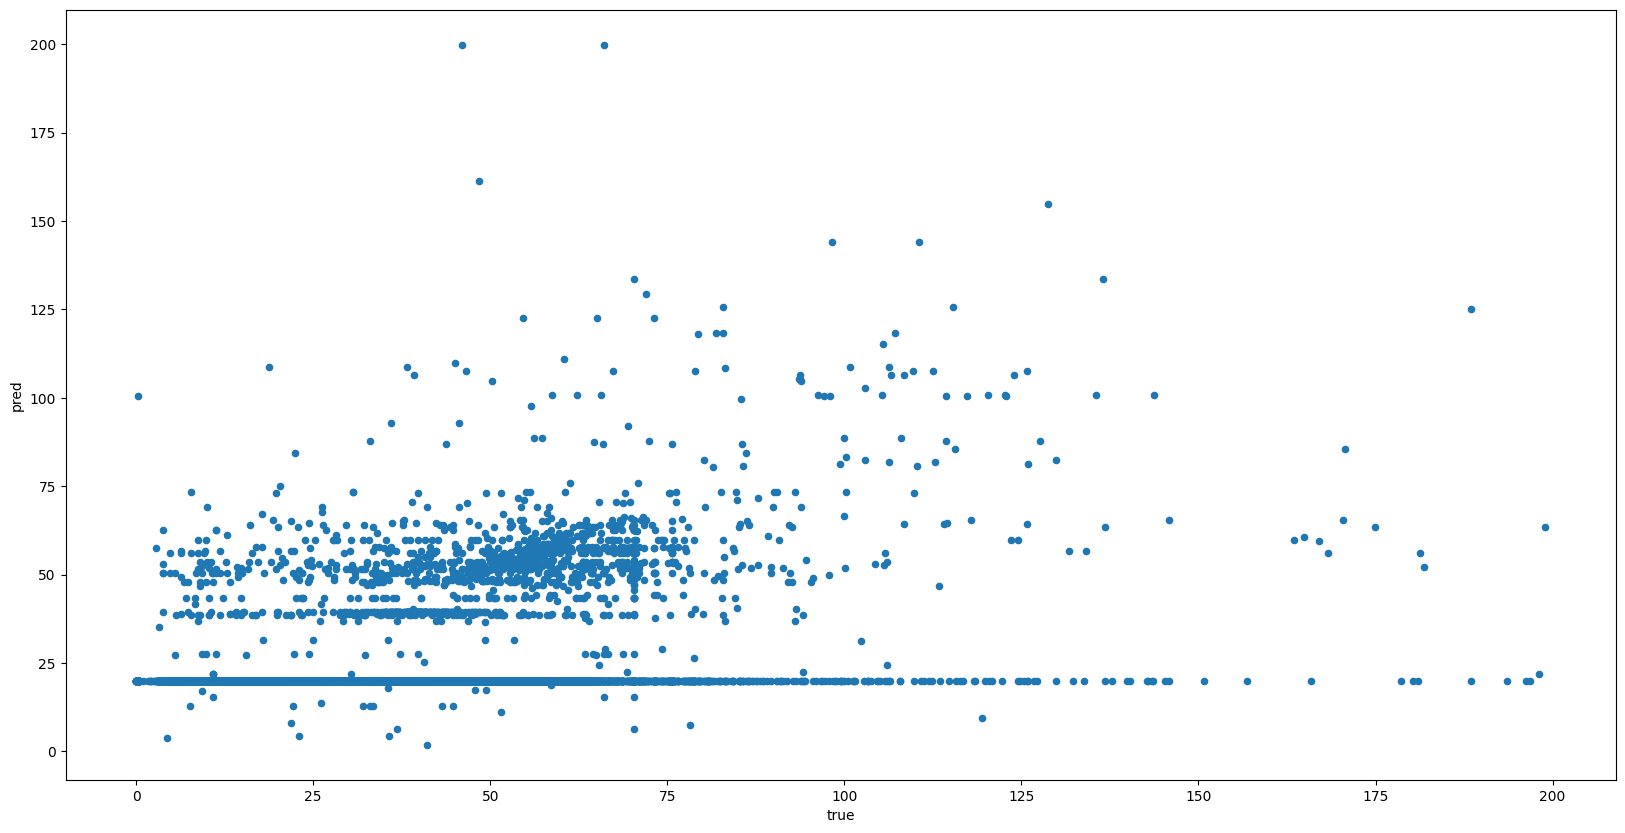

In [55]:
data = {
    'true': np.ravel(y_test),
    'pred': np.ravel(y_pred)
}
results = pd.DataFrame(data)

results.plot(figsize=(20,10), kind='scatter', x='true', y='pred')

## Feature Engineering

In [56]:
taxi_grouped_by_region.head()

,PULocationID,transaction_date,transaction_month,transaction_day,transaction_hour,trip_distance,total_amount,count_of_transaction
0,1,2019-01-01,1,1,2,0.0,21.800,1
1,1,2019-01-01,1,1,5,0.0,87.300,1
2,1,2019-01-01,1,1,6,0.0,80.300,1
3,1,2019-01-01,1,1,8,0.0,128.580,2
4,1,2019-01-01,1,1,10,16.9,43.245,4


In [57]:
data_with_new_features = taxi_grouped_by_region.copy()

#### Date-related Features

In [58]:
data_with_new_features['transaction_week_day'] = data_with_new_features ['transaction_date'].dt.weekday
data_with_new_features['weekend'] = data_with_new_features ['transaction_week_day'].apply(lambda x: True if x == 5 or x == 6 else False)

In [59]:
from pandas.tseries.holiday import USFederalHolidayCalendar

cal = USFederalHolidayCalendar()
holidays = cal.holidays(start='2018',
                      end='2020').date
data_with_new_features['is_holiday'] = data_with_new_features['transaction_date'].isin(holidays)

C:\Users\HP\AppData\Local\Temp\ipykernel_15540\1679111281.py:6: FutureWarning: The behavior of 'isin' with dtype=datetime64[ns] and castable values (e.g. strings) is deprecated. In a future version, these will not be considered matching by isin. Explicitly cast to the appropriate dtype before calling isin instead.
  data_with_new_features['is_holiday'] = data_with_new_features['transaction_date'].isin(holidays)


In [60]:
data_with_new_features.head()

,PULocationID,transaction_date,transaction_month,transaction_day,transaction_hour,trip_distance,total_amount,count_of_transaction,transaction_week_day,weekend,is_holiday
0,1,2019-01-01,1,1,2,0.0,21.800,1,1,False,True
1,1,2019-01-01,1,1,5,0.0,87.300,1,1,False,True
2,1,2019-01-01,1,1,6,0.0,80.300,1,1,False,True
3,1,2019-01-01,1,1,8,0.0,128.580,2,1,False,True
4,1,2019-01-01,1,1,10,16.9,43.245,4,1,False,True


####  Borough Information

In [61]:
zone_lookup = pd.read_csv(r"C:\Users\HP\Downloads\taxi_zone_lookup.csv")
zone_lookup = zone_lookup [['LocationID', 'Borough']]
zone_lookup['LocationID'] = zone_lookup['LocationID'].astype(str)
zone_lookup.head()

,LocationID,Borough
0,1,EWR
1,2,Queens
2,3,Bronx
3,4,Manhattan
4,5,Staten Island


In [62]:
data_with_new_features = data_with_new_features.merge(zone_lookup, left_on='PULocationID', right_on ='LocationID', how ='left')
data_with_new_features.drop('LocationID', axis=1, inplace=True)
data_with_new_features.head()

,PULocationID,transaction_date,transaction_month,transaction_day,transaction_hour,trip_distance,total_amount,count_of_transaction,transaction_week_day,weekend,is_holiday,Borough
0,1,2019-01-01,1,1,2,0.0,21.800,1,1,False,True,EWR
1,1,2019-01-01,1,1,5,0.0,87.300,1,1,False,True,EWR
2,1,2019-01-01,1,1,6,0.0,80.300,1,1,False,True,EWR
3,1,2019-01-01,1,1,8,0.0,128.580,2,1,False,True,EWR
4,1,2019-01-01,1,1,10,16.9,43.245,4,1,False,True,EWR


In [63]:
data_with_new_features['Borough'].value_counts()

Borough
Manhattan        45309
Brooklyn         23633
Queens           21942
Bronx             9586
Unknown            744
Staten Island      302
EWR                271
Name: count, dtype: int64

#### Weather-related Features

In [64]:
nyc_weather = pd.read_csv(r"C:\Users\HP\Downloads\nyc_weather_2019.csv")

In [65]:
nyc_weather.head()

,date_time,cloud_cover_%,humidity_%,precipitation_in,temperature_F,windspeed_mph
0,2019-01-01 00:00:00,36.1,72.6,0.0,28.6,14.1
1,2019-01-01 01:00:00,36.9,54.4,0.0,26.2,16.5
2,2019-01-01 02:00:00,27.3,55.3,0.0,30.0,17.1
3,2019-01-01 03:00:00,27.7,69.4,0.0,34.4,20.4
4,2019-01-01 04:00:00,22.9,64.3,0.0,28.6,21.8


In [66]:
nyc_weather.shape

(8760, 6)

In [67]:
nyc_weather.dtypes

date_time            object
cloud_cover_%       float64
humidity_%          float64
precipitation_in    float64
temperature_F       float64
windspeed_mph       float64
dtype: object

In [68]:
nyc_weather['cloud_cover_%'].value_counts()

cloud_cover_%
100.0    223
0.0      181
59.9      25
37.9      24
41.2      24
        ... 
92.3       1
0.1        1
1.1        1
1.6        1
99.9       1
Name: count, Length: 984, dtype: int64

In [69]:
nyc_weather['precipitation_in'].value_counts()

precipitation_in
0.00    7595
0.01     163
0.02     122
0.03     121
0.04      90
0.05      76
0.06      69
0.08      65
0.07      58
0.09      51
0.10      45
0.11      37
0.12      36
0.13      25
0.14      25
0.15      24
0.17      23
0.16      19
0.18      15
0.21      13
0.25       9
0.20       9
0.19       9
0.26       8
0.24       7
0.22       7
0.28       5
0.23       5
0.30       3
0.33       3
0.29       3
0.27       3
0.37       2
0.32       2
0.40       2
0.36       2
0.35       2
0.31       1
0.42       1
0.44       1
0.39       1
0.51       1
0.38       1
0.34       1
Name: count, dtype: int64

In [70]:
nyc_weather.isna().sum()

date_time           0
cloud_cover_%       0
humidity_%          0
precipitation_in    0
temperature_F       0
windspeed_mph       0
dtype: int64

In [71]:
nyc_weather['date_time'] = pd.to_datetime(nyc_weather['date_time'], errors='coerce')

In [72]:
nyc_weather.loc[:,'date_time'] = pd.to_datetime(nyc_weather.loc[:,'date_time'])
nyc_weather['hour'] = nyc_weather['date_time'].dt.hour
nyc_weather['month'] = nyc_weather['date_time'].dt.month
nyc_weather['day'] = nyc_weather['date_time'].dt.day

In [73]:
nyc_weather.head()

,date_time,cloud_cover_%,humidity_%,precipitation_in,temperature_F,windspeed_mph,hour,month,day
0,2019-01-01 00:00:00,36.1,72.6,0.0,28.6,14.1,0,1,1
1,2019-01-01 01:00:00,36.9,54.4,0.0,26.2,16.5,1,1,1
2,2019-01-01 02:00:00,27.3,55.3,0.0,30.0,17.1,2,1,1
3,2019-01-01 03:00:00,27.7,69.4,0.0,34.4,20.4,3,1,1
4,2019-01-01 04:00:00,22.9,64.3,0.0,28.6,21.8,4,1,1


In [74]:
data_with_new_features.head()

,PULocationID,transaction_date,transaction_month,transaction_day,transaction_hour,trip_distance,total_amount,count_of_transaction,transaction_week_day,weekend,is_holiday,Borough
0,1,2019-01-01,1,1,2,0.0,21.800,1,1,False,True,EWR
1,1,2019-01-01,1,1,5,0.0,87.300,1,1,False,True,EWR
2,1,2019-01-01,1,1,6,0.0,80.300,1,1,False,True,EWR
3,1,2019-01-01,1,1,8,0.0,128.580,2,1,False,True,EWR
4,1,2019-01-01,1,1,10,16.9,43.245,4,1,False,True,EWR


In [75]:
nyc_taxi_with_weather = data_with_new_features.merge(nyc_weather, left_on = ['transaction_month','transaction_day','transaction_hour'], right_on = ['month','day','hour'], how='left')

print(nyc_taxi_with_weather.shape)
nyc_taxi_with_weather.head()

(102496, 21)


,PULocationID,transaction_date,transaction_month,transaction_day,transaction_hour,trip_distance,total_amount,count_of_transaction,transaction_week_day,weekend,...,Borough,date_time,cloud_cover_%,humidity_%,precipitation_in,temperature_F,windspeed_mph,hour,month,day
0,1,2019-01-01,1,1,2,0.0,21.800,1,1,False,...,EWR,2019-01-01 02:00:00,27.3,55.3,0.0,30.0,17.1,2,1,1
1,1,2019-01-01,1,1,5,0.0,87.300,1,1,False,...,EWR,2019-01-01 05:00:00,26.6,61.2,0.0,30.1,19.5,5,1,1
2,1,2019-01-01,1,1,6,0.0,80.300,1,1,False,...,EWR,2019-01-01 06:00:00,65.5,72.9,0.0,38.9,13.8,6,1,1
3,1,2019-01-01,1,1,8,0.0,128.580,2,1,False,...,EWR,2019-01-01 08:00:00,47.4,65.2,0.0,33.7,15.1,8,1,1
4,1,2019-01-01,1,1,10,16.9,43.245,4,1,False,...,EWR,2019-01-01 10:00:00,55.3,61.8,0.0,35.9,15.9,10,1,1


In [76]:
nyc_taxi_with_weather = nyc_taxi_with_weather.drop(['date_time','hour','month','day'], axis=1)

In [77]:
nyc_taxi_with_weather.head()

,PULocationID,transaction_date,transaction_month,transaction_day,transaction_hour,trip_distance,total_amount,count_of_transaction,transaction_week_day,weekend,is_holiday,Borough,cloud_cover_%,humidity_%,precipitation_in,temperature_F,windspeed_mph
0,1,2019-01-01,1,1,2,0.0,21.800,1,1,False,True,EWR,27.3,55.3,0.0,30.0,17.1
1,1,2019-01-01,1,1,5,0.0,87.300,1,1,False,True,EWR,26.6,61.2,0.0,30.1,19.5
2,1,2019-01-01,1,1,6,0.0,80.300,1,1,False,True,EWR,65.5,72.9,0.0,38.9,13.8
3,1,2019-01-01,1,1,8,0.0,128.580,2,1,False,True,EWR,47.4,65.2,0.0,33.7,15.1
4,1,2019-01-01,1,1,10,16.9,43.245,4,1,False,True,EWR,55.3,61.8,0.0,35.9,15.9


In [78]:
nyc_taxi_with_weather.isna().sum()

PULocationID              0
transaction_date          0
transaction_month         0
transaction_day           0
transaction_hour          0
trip_distance             0
total_amount              0
count_of_transaction      0
transaction_week_day      0
weekend                   0
is_holiday                0
Borough                 709
cloud_cover_%             0
humidity_%                0
precipitation_in          0
temperature_F             0
windspeed_mph             0
dtype: int64

In [79]:
nyc_taxi_with_weather = nyc_taxi_with_weather.sort_values(['transaction_date','transaction_hour']).reset_index().drop('index',axis=1)

In [80]:
nyc_taxi_with_weather = nyc_taxi_with_weather.dropna()
nyc_taxi_with_weather.isna().sum()

PULocationID            0
transaction_date        0
transaction_month       0
transaction_day         0
transaction_hour        0
trip_distance           0
total_amount            0
count_of_transaction    0
transaction_week_day    0
weekend                 0
is_holiday              0
Borough                 0
cloud_cover_%           0
humidity_%              0
precipitation_in        0
temperature_F           0
windspeed_mph           0
dtype: int64

In [81]:
nyc_taxi_with_weather.head()

,PULocationID,transaction_date,transaction_month,transaction_day,transaction_hour,trip_distance,total_amount,count_of_transaction,transaction_week_day,weekend,is_holiday,Borough,cloud_cover_%,humidity_%,precipitation_in,temperature_F,windspeed_mph
0,10,2019-01-01,1,1,0,3.020000,14.300000,2,1,False,True,Queens,36.1,72.6,0.0,28.6,14.1
1,100,2019-01-01,1,1,0,2.801852,18.130000,54,1,False,True,Manhattan,36.1,72.6,0.0,28.6,14.1
2,106,2019-01-01,1,1,0,2.593333,15.373333,3,1,False,True,Brooklyn,36.1,72.6,0.0,28.6,14.1
3,107,2019-01-01,1,1,0,2.437458,14.897458,421,1,False,True,Manhattan,36.1,72.6,0.0,28.6,14.1
4,11,2019-01-01,1,1,0,1.795000,9.300000,2,1,False,True,Brooklyn,36.1,72.6,0.0,28.6,14.1


## Model Training

In [82]:
data_for_model = nyc_taxi_with_weather.copy()

In [83]:
categorical_features = ['PULocationID', 'transaction_month','transaction_day','transaction_hour','transaction_week_day', 'weekend','is_holiday', 'Borough',]
input_features = categorical_features + ['cloud_cover_%','humidity_%', 'precipitation_in','temperature_F','windspeed_mph']
target_features = ['total_amount']

#### Train / Test Spilt

In [84]:
from sklearn.model_selection import train_test_split
X = data_for_model[input_features]
y= data_for_model[target_features]

X = pd.get_dummies(X)

X_train,X_test,y_train,y_test = train_test_split(X, y, test_size=0.33, random_state=42)

#### Decision Tree

In [85]:
from sklearn.tree import DecisionTreeRegressor
tree = DecisionTreeRegressor(max_depth=10)
tree.fit(X_train,y_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [86]:
model_at_hand = tree

y_pred = model_at_hand.predict(X_test)
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
from math import sqrt

print('mean_absolute_error', mean_absolute_error(y_test, y_pred))
print('mean_squared_error', mean_squared_error(y_test, y_pred))
print('root_mean_squared_error', sqrt(mean_squared_error(y_test, y_pred)))
print('r2', r2_score(y_test, y_pred))

mean_absolute_error 8.294767847598727
mean_squared_error 186.2178443447218
root_mean_squared_error 13.646165921046167
r2 0.2955248964040602


<Axes: xlabel='true', ylabel='pred'>

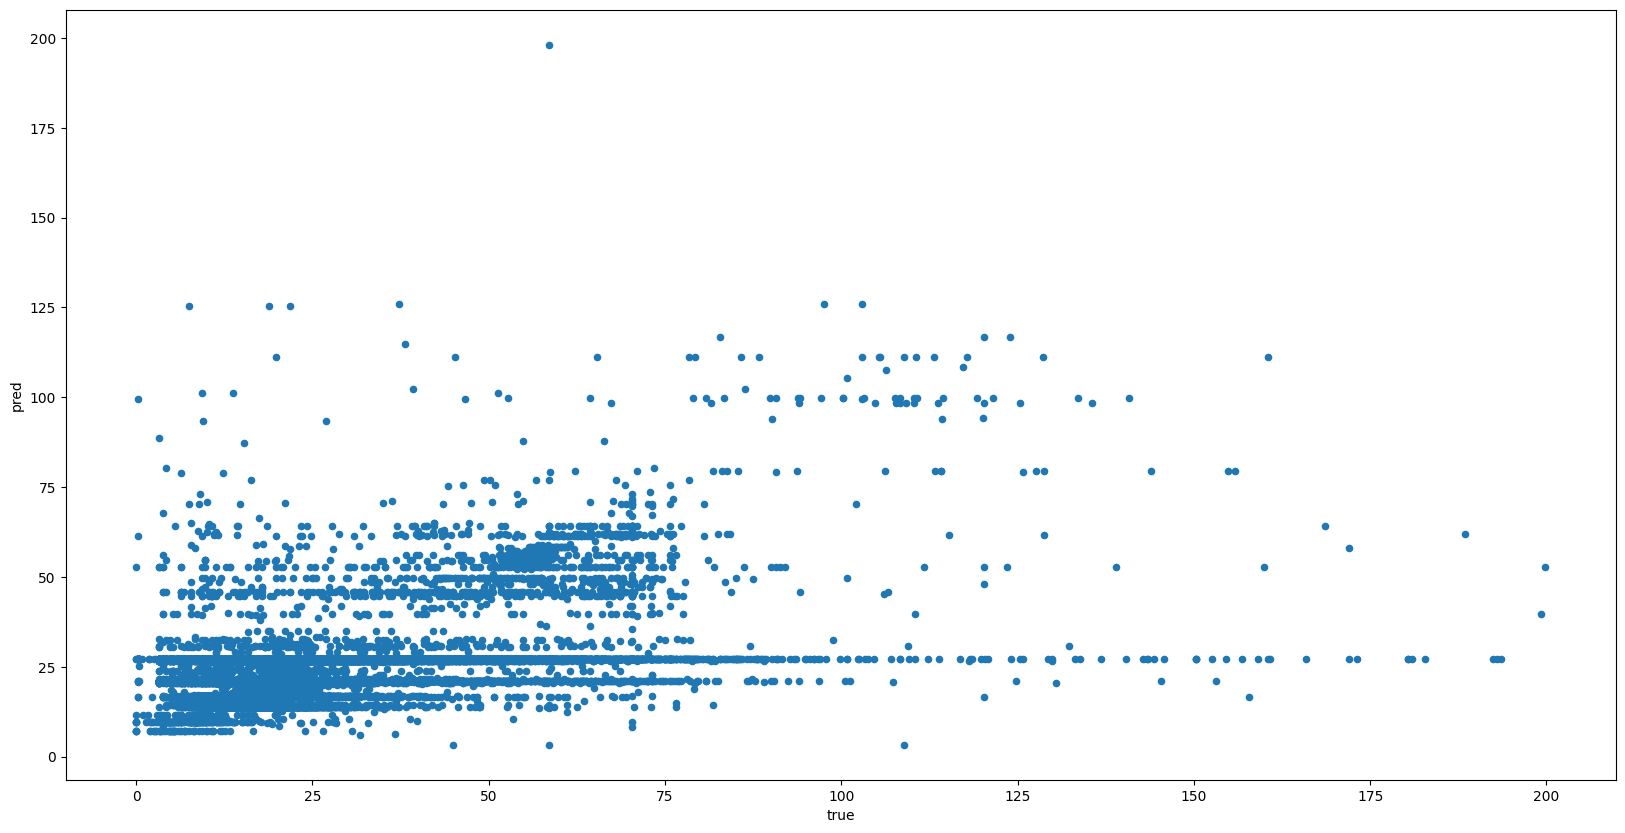

In [87]:
data = {
    'true': np.ravel(y_test),
    'pred': np.ravel(y_pred)
}
results = pd.DataFrame(data)

results.plot(figsize=(20,10), kind='scatter', x='true', y='pred')

#### Random Forest

In [88]:
from sklearn.ensemble import RandomForestRegressor

Forest_model = RandomForestRegressor()
Forest_model.fit(X_train,y_train)

C:\Users\HP\Downloads\Anaconda\envs\tf210\lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [89]:
model_at_hand = Forest_model

y_pred = model_at_hand.predict(X_test)
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
from math import sqrt

print('mean_absolute_error', mean_absolute_error(y_test, y_pred))
print('mean_squared_error', mean_squared_error(y_test, y_pred))
print('root_mean_squared_error', sqrt(mean_squared_error(y_test, y_pred)))
print('r2', r2_score(y_test, y_pred))

mean_absolute_error 7.1125103944774875
mean_squared_error 162.2422073854755
root_mean_squared_error 12.73743331230729
r2 0.386226404576268


<Axes: xlabel='true', ylabel='pred'>

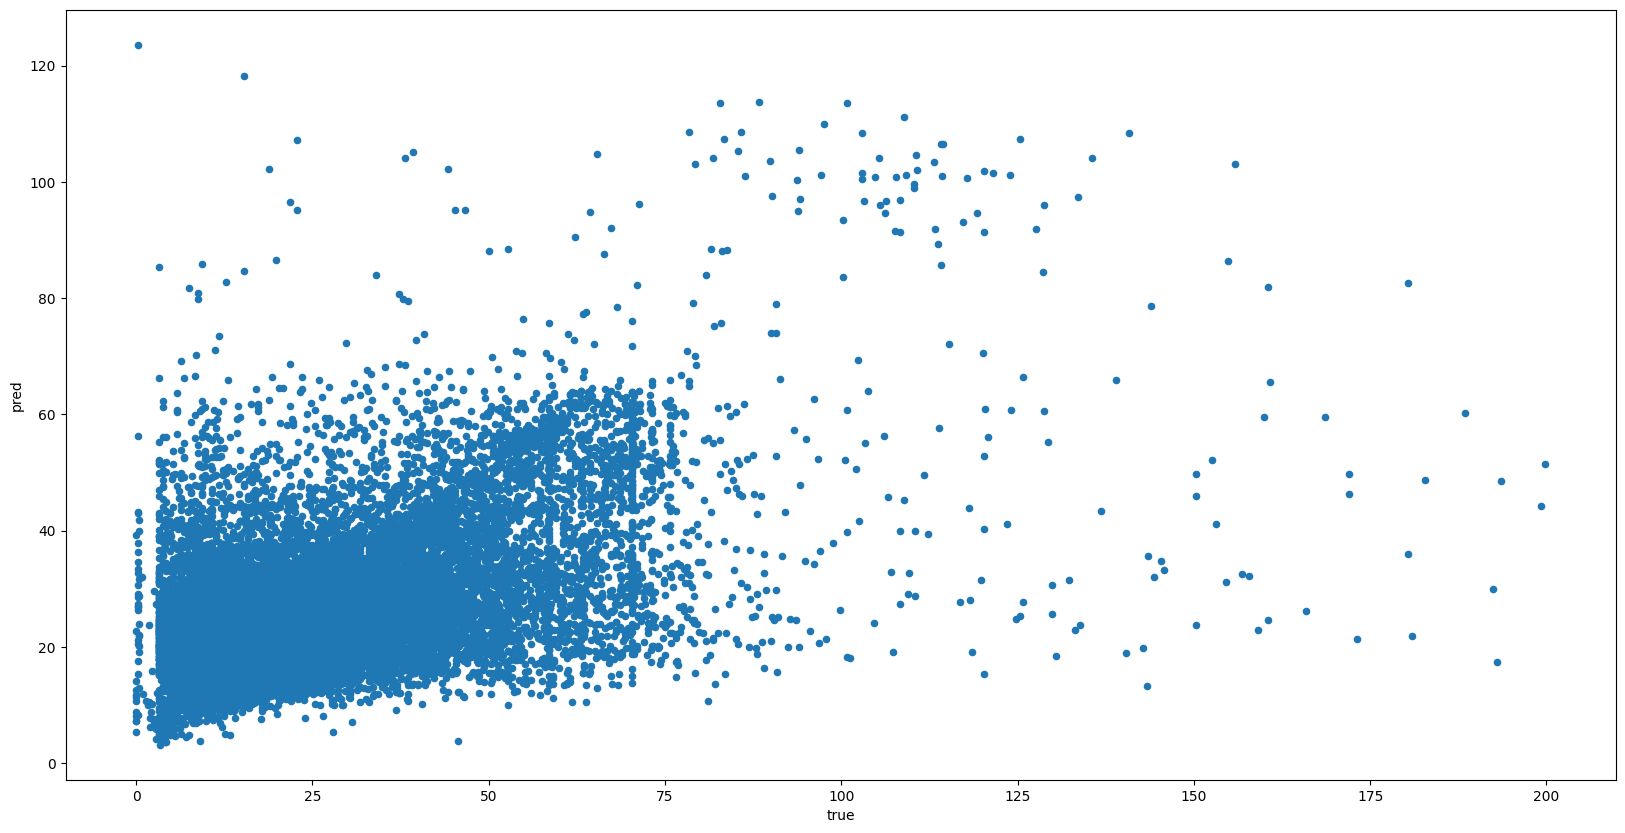

In [90]:
data = {
    'true': np.ravel(y_test),
    'pred': np.ravel(y_pred)
}
results = pd.DataFrame(data)

results.plot(figsize=(20,10), kind='scatter', x='true', y='pred')

#### Gradient Boosting

In [91]:
from sklearn.ensemble import GradientBoostingRegressor

GB_model = GradientBoostingRegressor()
GB_model.fit(X_train,y_train)

C:\Users\HP\Downloads\Anaconda\envs\tf210\lib\site-packages\sklearn\ensemble\_gb.py:672: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)  # TODO: Is this still required?


,loss,'squared_error'
,learning_rate,0.1
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


In [92]:
model_at_hand = GB_model

y_pred = model_at_hand.predict(X_test)
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
from math import sqrt

print('mean_absolute_error', mean_absolute_error(y_test, y_pred))
print('mean_squared_error', mean_squared_error(y_test, y_pred))
print('root_mean_squared_error', sqrt(mean_squared_error(y_test, y_pred)))
print('r2', r2_score(y_test, y_pred))

mean_absolute_error 8.153978960247853
mean_squared_error 170.20888295930973
root_mean_squared_error 13.046412647134451
r2 0.3560879147879171


<Axes: xlabel='true', ylabel='pred'>

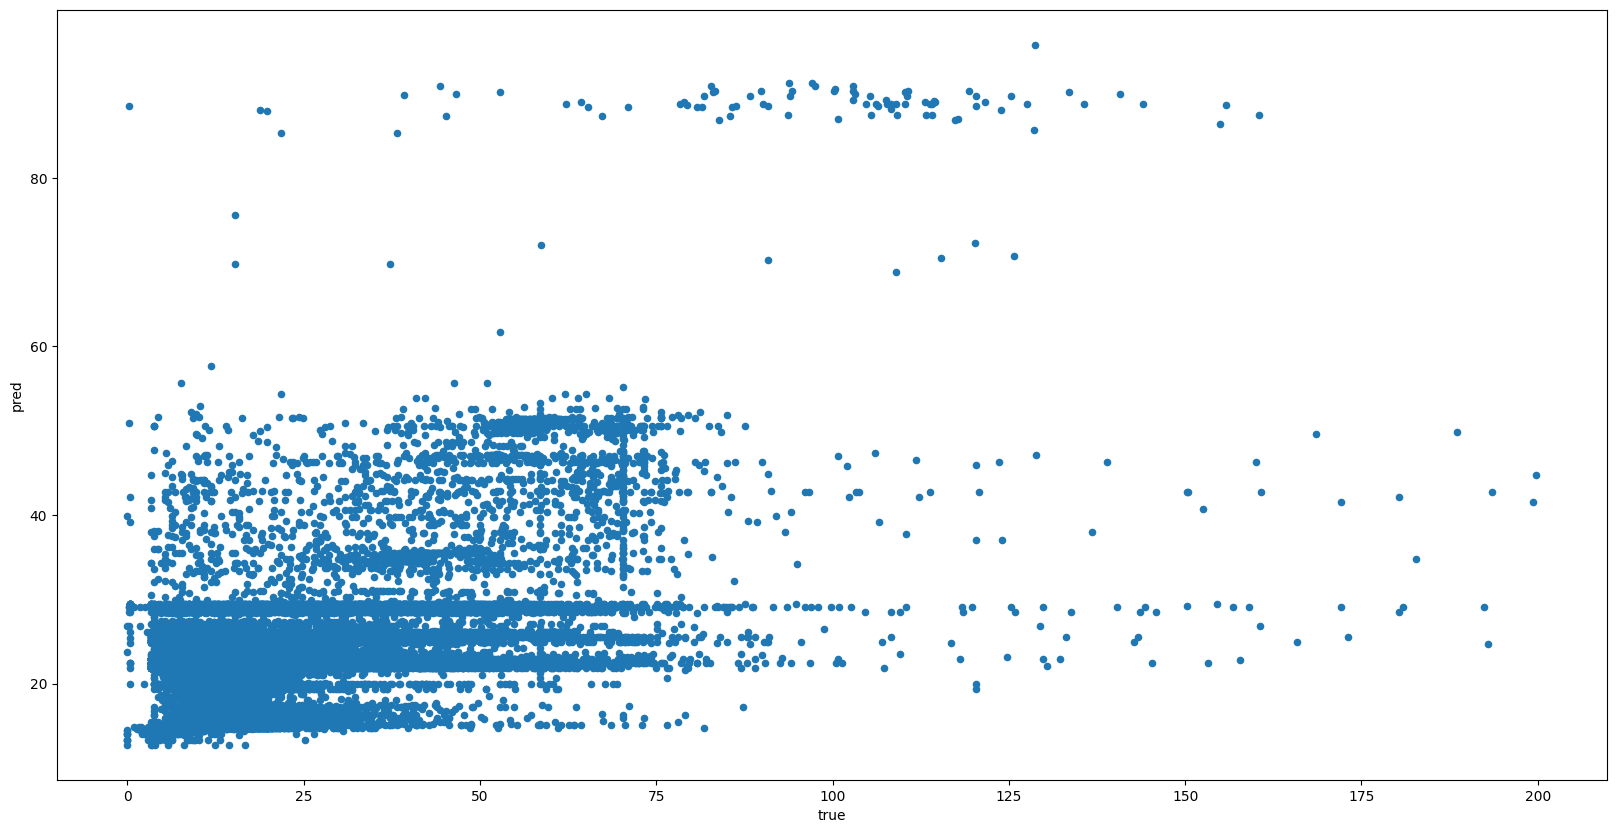

In [93]:
data = {
    'true': np.ravel(y_test),
    'pred': np.ravel(y_pred)
}
results = pd.DataFrame(data)

results.plot(figsize=(20,10), kind='scatter', x='true', y='pred')

<Axes: >

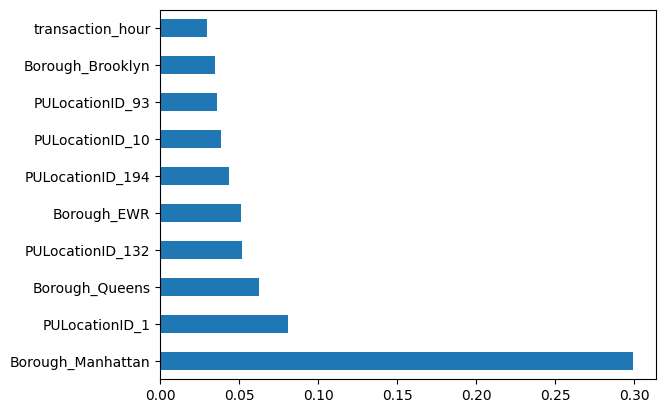

In [94]:
(pd.Series(model_at_hand.feature_importances_, index=X_train.columns)
    .nlargest(10)
    .plot(kind='barh'))

#### Tuning of Random Forest model

In [95]:
# Number of trees in random forest
n_estimators = [int(x) for x in np.linspace(start = 200, stop = 2000, num = 10)]
# Number of features to consider at every split
max_features = ['auto', 'sqrt']
# Maximum number of levels in tree
max_depth = [10,20,50,100,150,200,300,500]
max_depth.append(None)
# Minimum number of samples required to split a node
min_samples_split = [2, 5, 10, 20, 40]
# Minimum number of samples required at each leaf node
min_samples_leaf = [1, 2, 4, 10, 20]
# Method of selecting samples for training each tree
bootstrap = [True, False]

In [96]:
import pprint as pp

# Create the random grid
random_grid = {'n_estimators': n_estimators,
               'max_features': max_features,
               'max_depth': max_depth,
               'min_samples_split': min_samples_split,
               'min_samples_leaf': min_samples_leaf,
               'bootstrap': bootstrap}
pp.pprint(random_grid)

{'bootstrap': [True, False],
 'max_depth': [10, 20, 50, 100, 150, 200, 300, 500, None],
 'max_features': ['auto', 'sqrt'],
 'min_samples_leaf': [1, 2, 4, 10, 20],
 'min_samples_split': [2, 5, 10, 20, 40],
 'n_estimators': [200, 400, 600, 800, 1000, 1200, 1400, 1600, 1800, 2000]}


In [97]:
from sklearn.model_selection import RandomizedSearchCV

rf = RandomForestRegressor()

rf_random = RandomizedSearchCV(estimator = rf, param_distributions = random_grid, n_iter = 10, cv = 3, verbose=2, random_state=42, n_jobs = -1)

# Fit the random search model
rf_random.fit(X_train, y_train)

performances = pd.DataFrame.from_dict(rf_random.cv_results_)

Fitting 3 folds for each of 10 candidates, totalling 30 fits


C:\Users\HP\Downloads\Anaconda\envs\tf210\lib\site-packages\sklearn\model_selection\_validation.py:516: FitFailedWarning: 
9 fits failed out of a total of 30.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
6 fits failed with the following error:
Traceback (most recent call last):
  File "C:\Users\HP\Downloads\Anaconda\envs\tf210\lib\site-packages\sklearn\model_selection\_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "C:\Users\HP\Downloads\Anaconda\envs\tf210\lib\site-packages\sklearn\base.py", line 1358, in wrapper
    estimator._validate_params()
  File "C:\Users\HP\Downloads\Anaconda\envs\tf210\lib\site-packages\sklearn\base.py", line 471, in _validate_params
    validate_paramete

In [98]:
performances

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_n_estimators,param_min_samples_split,param_min_samples_leaf,param_max_features,param_max_depth,param_bootstrap,params,split0_test_score,split1_test_score,split2_test_score,mean_test_score,std_test_score,rank_test_score
0,182.628342,11.325214,8.982557,1.124095,200,10,1,sqrt,200,False,"{'n_estimators': 200, 'min_samples_split': 10,...",0.407107,0.412207,0.419752,0.413022,0.005194,2
1,58.130077,5.741309,2.983517,0.945872,200,5,4,sqrt,20,True,"{'n_estimators': 200, 'min_samples_split': 5, ...",0.350160,0.349655,0.357063,0.352293,0.003379,6
2,85.988238,1.448076,2.111731,0.459385,200,40,4,sqrt,20,False,"{'n_estimators': 200, 'min_samples_split': 40,...",0.351736,0.348681,0.360765,0.353727,0.005130,5
3,0.331884,0.049912,0.000000,0.000000,400,40,10,auto,20,False,"{'n_estimators': 400, 'min_samples_split': 40,...",NaN,NaN,NaN,NaN,NaN,8
4,0.248488,0.073715,0.000000,0.000000,1000,20,20,auto,50,False,"{'n_estimators': 1000, 'min_samples_split': 20...",NaN,NaN,NaN,NaN,NaN,8
5,1000.564672,14.098060,92.646380,0.348316,1200,5,1,sqrt,100,False,"{'n_estimators': 1200, 'min_samples_split': 5,...",0.400976,0.407159,0.415138,0.407758,0.005797,3
6,185.480992,6.356598,5.107291,0.176773,1400,5,20,sqrt,10,True,"{'n_estimators': 1400, 'min_samples_split': 5,...",0.268062,0.260167,0.271140,0.266456,0.004622,7
7,559.118519,13.721431,27.408528,3.786733,1400,10,10,sqrt,None,True,"{'n_estimators': 1400, 'min_samples_split': 10...",0.396064,0.397644,0.403736,0.399148,0.003308,4
8,0.172441,0.033224,0.000000,0.000000,1800,10,2,auto,50,False,"{'n_estimators': 1800, 'min_samples_split': 10...",NaN,NaN,NaN,NaN,NaN,8
9,410.975534,63.176913,19.771280,4.392320,600,10,2,sqrt,500,False,"{'n_estimators': 600, 'min_samples_split': 10,...",0.411867,0.417069,0.424277,0.417737,0.005088,1


##### Best Random Forest Model

In [99]:
import time
t0= time.time()

best = RandomForestRegressor(n_estimators=200,min_samples_split= 10,
min_samples_leaf= 1,
max_features= 'sqrt',
max_depth= 200,
bootstrap= False)
best.fit(X_train, y_train)

t1 = time.time() - t0
print("Time elapsed: ", t1, " seconds")


model_at_hand = best

y_pred = model_at_hand.predict(X_test)

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
from math import sqrt

print('mean_absolute_error', mean_absolute_error(y_test, y_pred))
print('mean_squared_error', mean_squared_error(y_test, y_pred))
print('root_mean_squared_error', sqrt(mean_squared_error(y_test, y_pred)))
print('r2', r2_score(y_test, y_pred))

C:\Users\HP\Downloads\Anaconda\envs\tf210\lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


Time elapsed:  72.10086274147034  seconds
mean_absolute_error 7.0628329605717735
mean_squared_error 153.85721588648818
root_mean_squared_error 12.403919376007254
r2 0.41794741270890023


In [100]:
import time
t0= time.time()

best = RandomForestRegressor(n_estimators=600,min_samples_split= 10,
min_samples_leaf= 2,
max_features= 'sqrt',
max_depth= 500,
bootstrap= True)
best.fit(X_train, y_train)

t1 = time.time() - t0
print("Time elapsed: ", t1, " seconds")


model_at_hand = best

y_pred = model_at_hand.predict(X_test)

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
from math import sqrt

print('mean_absolute_error', mean_absolute_error(y_test, y_pred))
print('mean_squared_error', mean_squared_error(y_test, y_pred))
print('root_mean_squared_error', sqrt(mean_squared_error(y_test, y_pred)))
print('r2', r2_score(y_test, y_pred))

C:\Users\HP\Downloads\Anaconda\envs\tf210\lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


Time elapsed:  166.039293050766  seconds
mean_absolute_error 7.151960477224498
mean_squared_error 152.81279255153277
root_mean_squared_error 12.361747148018065
r2 0.4218985390882213


<Axes: xlabel='true', ylabel='pred'>

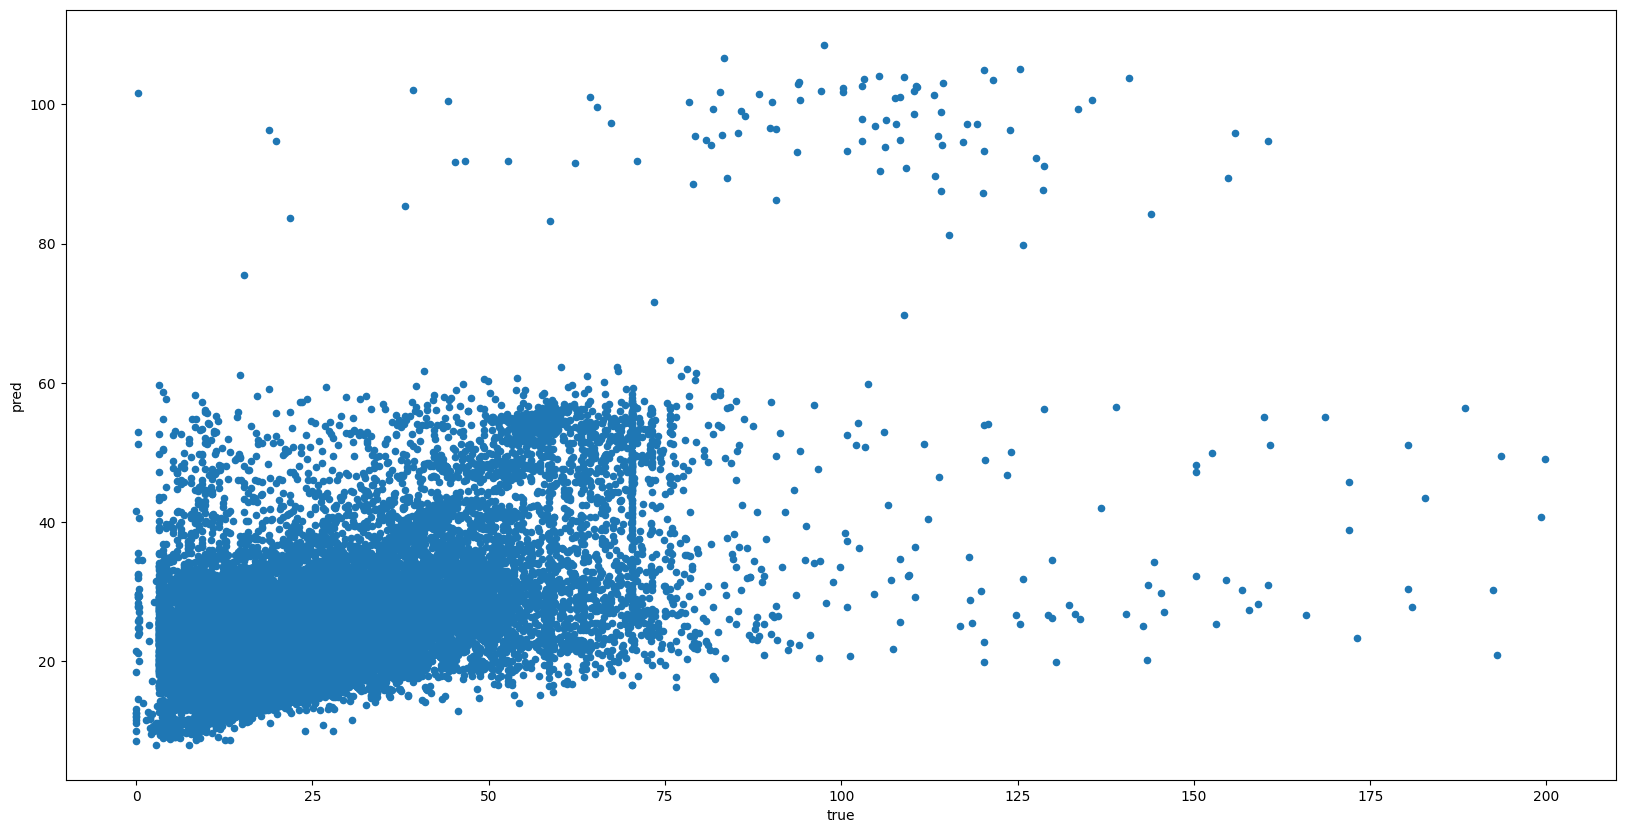

In [101]:

data = {
    'true': np.ravel(y_test),
    'pred': np.ravel(y_pred)
}
results = pd.DataFrame(data)

results.plot(figsize=(20,10), kind='scatter', x='true', y='pred')

In [102]:
print(data_for_model.shape)
print(X_train.shape)

(101787, 17)
(68197, 280)


#### Neural Network

In [114]:
# Check total_amount has extreme outliers
print(y_train.min())
print(y_train.max())
print(y_train.mean())
print(y_train.median())

total_amount    0.0
dtype: float64
total_amount    199.3
dtype: float64
total_amount    21.405213
dtype: float64
total_amount    15.269951
dtype: float64


In [103]:
y_train_NN = y_train.values.astype('float32')
y_test_NN = y_test.values.astype('float32')

In [104]:
X_test_NN = X_test.astype(np.float32).to_numpy()
X_train_NN = X_train.astype(np.float32).to_numpy()

print(X_test_NN.dtype)
print(X_train_NN.dtype)

float32
float32


In [105]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_NN)
X_test_scaled = scaler.transform(X_test_NN)

In [106]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

NN_model = keras.Sequential([
    layers.Input(shape=(280,)),

    layers.Dense(256, activation='relu'),
    layers.Dropout(0.2),

    layers.Dense(128, activation='relu'),
    layers.Dropout(0.2),

    layers.Dense(64, activation='relu'),

    layers.Dense(1)
])

In [106]:
NN_model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

In [107]:
NN_model.compile(
    optimizer='adam',
    loss='huber',
    metrics=['mae']
)

In [108]:
early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

In [109]:
history = NN_model.fit(
    X_train_scaled,
    y_train_NN,
    validation_split=0.2,
    epochs=100,
    batch_size=256,
    callbacks=[early_stop]
)

Epoch 1/100
214/214 [==============================] - 3s 7ms/step - loss: 8.1065 - mae: 8.5792 - val_loss: 6.8090 - val_mae: 7.2687
Epoch 2/100
214/214 [==============================] - 1s 5ms/step - loss: 7.0188 - mae: 7.4857 - val_loss: 6.8525 - val_mae: 7.3141
Epoch 3/100
214/214 [==============================] - 1s 6ms/step - loss: 6.9389 - mae: 7.4045 - val_loss: 6.7470 - val_mae: 7.2070
Epoch 4/100
214/214 [==============================] - 1s 5ms/step - loss: 6.8874 - mae: 7.3526 - val_loss: 6.8910 - val_mae: 7.3556
Epoch 5/100
214/214 [==============================] - 1s 7ms/step - loss: 6.8647 - mae: 7.3290 - val_loss: 6.8899 - val_mae: 7.3542
Epoch 6/100
214/214 [==============================] - 3s 13ms/step - loss: 6.8361 - mae: 7.3005 - val_loss: 6.9115 - val_mae: 7.3778
Epoch 7/100
214/214 [==============================] - 3s 12ms/step - loss: 6.8156 - mae: 7.2785 - val_loss: 6.8571 - val_mae: 7.3210
Epoch 8/100
214/214 [==============================] - 3s 12ms/step

In [112]:
loss, mae = NN_model.evaluate(X_test_scaled, y_test_NN)

y_pred_nn = NN_model.predict(X_test_scaled)

1050/1050 [==============================] - 2s 2ms/step


In [115]:
#Predictions should be in the same ballpark as the actual values.
print(y_pred_nn[:10].flatten())
print(y_test_NN[:10])

[17.861702  17.180595  15.0769415 14.637582  13.852602  14.43422
 22.31425   15.182972  16.183182  14.118617 ]
[[17.7     ]
 [14.234375]
 [10.644326]
 [16.24649 ]
 [19.193823]
 [11.04653 ]
 [20.713469]
 [19.526667]
 [10.065   ]
 [12.799412]]


In [113]:
from sklearn.metrics import mean_squared_error, r2_score
from math import sqrt

rmse = sqrt(mean_squared_error(y_test_NN, y_pred_nn))
r2 = r2_score(y_test_NN, y_pred_nn)

print("MAE:", mae)
print("RMSE:", rmse)
print("R²:", r2)

MAE: 7.195138454437256
RMSE: 12.86866737846838
R²: 0.37351375818252563


## Model Performance

In [116]:
comparison_df = pd.DataFrame({
    'Model': ['Random Forest #1', 'Random Forest #2', 'Neural Network'],
    'MAE': [7.070347784826874, 7.153648582318168, 7.195138454437256],
    'RMSE': [12.416206802159625, 12.361625063684961, 12.86866737846838],
    'R²': [0.4167936692273231, 0.4219099576655416, 0.37351375818252563]
})

comparison_df

,Model,MAE,RMSE,R²
0,Random Forest #1,7.070348,12.416207,0.416794
1,Random Forest #2,7.153649,12.361625,0.421910
2,Neural Network,7.195138,12.868667,0.373514


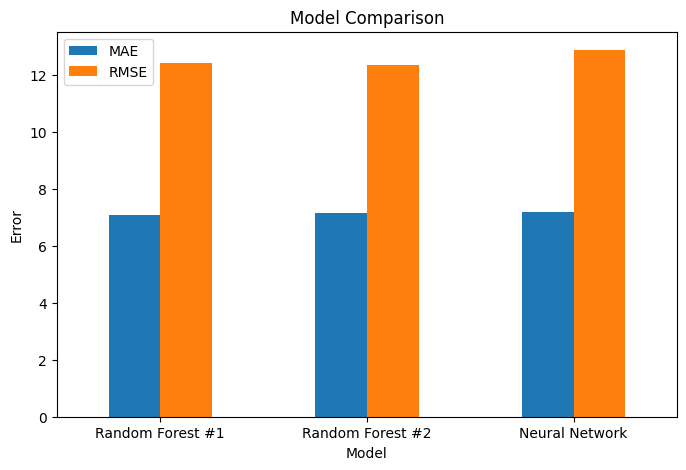

In [118]:
import matplotlib.pyplot as plt
comparison_df.set_index('Model')[['MAE', 'RMSE']].plot(
    kind='bar',
    figsize=(8,5)
)

plt.title('Model Comparison')
plt.ylabel('Error')
plt.xticks(rotation=0)
plt.show()

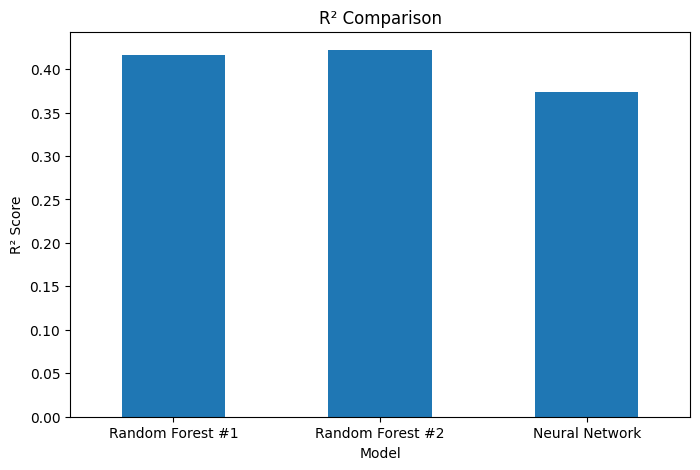

In [119]:
comparison_df.set_index('Model')['R²'].plot(
    kind='bar',
    figsize=(8,5)
)

plt.title('R² Comparison')
plt.ylabel('R² Score')
plt.xticks(rotation=0)
plt.show()